# User Journey Conversion Analysis
## 로그 기반 유저 여정 전환 분석

이 노트북은 `outputs/` 폴더에 저장된 SQL 분석 결과 CSV와 세션 단위 feature dataset을 불러와 유저 여정, 구매 전환, 구매 이후 리뷰 행동 분석 흐름을 정리합니다.

현재 단계에서는 기존 SQL 결과 CSV 로드와 시각화 흐름을 유지하고, 새로 추가된 `session_level_features.csv`를 불러와 모델링 전 데이터 검수까지만 수행합니다. Logistic Regression, Random Forest 등 구매 전환 예측 모델링 코드와 A/B 테스트 설계 코드는 아직 포함하지 않습니다.

**분석 한계:** 현재 프로젝트의 데이터는 synthetic data 기반입니다. 아래 그래프와 검수 결과는 데이터 생성 규칙과 분석 흐름을 검증하기 위한 용도로만 사용하며, 실제 이커머스 서비스의 사용자 행동이나 비즈니스 인사이트로 일반화하지 않습니다.


## 준비: 라이브러리, 경로, CSV 파일 확인

필요한 SQL 결과 CSV와 세션 단위 feature CSV가 모두 존재하는지 확인하고, 그래프 저장 폴더 `outputs/figures/`를 생성합니다.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Synthetic data 기반 결과이므로 실제 서비스 인사이트로 일반화하지 않습니다.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"

CSV_FILES = {
    "funnel_stage_conversion": OUTPUT_DIR / "funnel_stage_conversion.csv",
    "funnel_drop_off_summary": OUTPUT_DIR / "funnel_drop_off_summary.csv",
    "conversion_behavior_by_purchase_status": OUTPUT_DIR / "conversion_behavior_by_purchase_status.csv",
    "conversion_rate_by_event_reach": OUTPUT_DIR / "conversion_rate_by_event_reach.csv",
    "conversion_rate_by_add_to_cart_segment": OUTPUT_DIR / "conversion_rate_by_add_to_cart_segment.csv",
    "post_purchase_review_session_type_share": OUTPUT_DIR / "post_purchase_review_session_type_share.csv",
    "session_level_features": OUTPUT_DIR / "session_level_features.csv",
}

missing_files = [str(path) for path in CSV_FILES.values() if not path.exists()]
if missing_files:
    raise FileNotFoundError("Missing required CSV files:\n" + "\n".join(missing_files))

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
print(f"All required CSV files exist. Figures will be saved to: {FIGURE_DIR}")


All required CSV files exist. Figures will be saved to: c:\Users\wxlov\ANALYSIST\project\Log-Based-E-commerce-User-Journey-Analysis\outputs\figures


## CSV 로드

기존 SQL 분석 결과 CSV와 이후 구매 전환 예측 모델링에 사용할 세션 단위 feature CSV를 `DataFrame`으로 불러옵니다.


In [2]:
funnel_stage = pd.read_csv(CSV_FILES["funnel_stage_conversion"])
drop_off = pd.read_csv(CSV_FILES["funnel_drop_off_summary"])
behavior_by_purchase = pd.read_csv(CSV_FILES["conversion_behavior_by_purchase_status"])
event_reach = pd.read_csv(CSV_FILES["conversion_rate_by_event_reach"])
cart_segment = pd.read_csv(CSV_FILES["conversion_rate_by_add_to_cart_segment"])
review_type = pd.read_csv(CSV_FILES["post_purchase_review_session_type_share"])
session_features = pd.read_csv(CSV_FILES["session_level_features"])

funnel_stage


,funnel_stage,reached_session_count,session_start_reach_rate,previous_stage_conversion_rate
0,session_start,1000,100.0,NaN
1,view_item,867,86.7,86.70
2,add_to_cart,578,57.8,66.67
3,begin_checkout,366,36.6,63.32
4,purchase,282,28.2,77.05


## 1. 세션 단위 Feature Dataset 검수

`session_level_features.csv`는 이후 Python 기반 세션 단위 분석 및 구매 전환 모델링에 사용할 입력 데이터입니다. 이 섹션에서는 shape, 샘플 행, 결측치, target 분포, 기존 SQL 분석 결과의 구매 세션 수와의 일치 여부를 확인합니다. 이 단계에서는 모델링을 수행하지 않습니다.


### 1.1 Shape 확인


In [3]:
session_features.shape

(1000, 17)

### 1.2 Head 확인


In [4]:
session_features.head()


,session_id,user_id,event_count,search_count,view_item_list_count,view_item_count,add_to_cart_count,begin_checkout_count,unique_product_count,unique_category_count,session_duration_minutes,has_search,has_view_item_list,has_view_item,has_add_to_cart,has_begin_checkout,is_purchase
0,s001,u109,6,1,1,1,1,1,1,1,14,1,1,1,1,1,1
1,s002,u256,4,0,1,2,0,0,2,1,9,0,1,1,0,0,0
2,s003,u280,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,s004,u149,2,0,0,1,0,0,1,0,5,0,0,1,0,0,0
4,s005,u125,2,0,1,0,0,0,0,1,3,0,1,0,0,0,0


### 1.3 결측치 확인


In [5]:
missing_summary = (
    session_features
    .isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "column", 0: "missing_count"})
)
missing_summary["missing_share_pct"] = round(
    100.0 * missing_summary["missing_count"] / len(session_features),
    2,
)
missing_summary


,column,missing_count,missing_share_pct
0,session_id,0,0.0
1,user_id,0,0.0
2,event_count,0,0.0
3,search_count,0,0.0
4,view_item_list_count,0,0.0
5,view_item_count,0,0.0
6,add_to_cart_count,0,0.0
7,begin_checkout_count,0,0.0
8,unique_product_count,0,0.0
9,unique_category_count,0,0.0


### 1.4 is_purchase Target 분포 확인


In [6]:
target_distribution = (
    session_features["is_purchase"]
    .value_counts(dropna=False)
    .rename_axis("is_purchase")
    .reset_index(name="session_count")
    .sort_values("is_purchase", ascending=False)
)
target_distribution["session_share_pct"] = round(
    100.0 * target_distribution["session_count"] / target_distribution["session_count"].sum(),
    2,
)
target_distribution


,is_purchase,session_count,session_share_pct
1,1,282,28.2
0,0,718,71.8


### 1.5 구매 세션 수 일치 여부 확인

기존 SQL 분석 결과에서 확인한 구매 세션 수는 282개입니다. `session_level_features.csv`의 `is_purchase=1` 세션 수가 이 값과 일치하는지 확인합니다.


In [7]:
EXPECTED_PURCHASE_SESSION_COUNT = 282
actual_purchase_session_count = int((session_features["is_purchase"] == 1).sum())

purchase_session_count_check = pd.DataFrame({
    "metric": ["expected_purchase_session_count", "actual_purchase_session_count", "difference"],
    "value": [
        EXPECTED_PURCHASE_SESSION_COUNT,
        actual_purchase_session_count,
        actual_purchase_session_count - EXPECTED_PURCHASE_SESSION_COUNT,
    ],
})
purchase_session_count_check


,metric,value
0,expected_purchase_session_count,282
1,actual_purchase_session_count,282
2,difference,0


### 1.6 Feature / Target 컬럼 정의

`is_purchase`는 target 컬럼이며, 이후 구매 전환 예측 모델링의 정답값으로만 사용합니다. 이 단계에서는 `FEATURE_COLUMNS`, `TARGET_COLUMN`, `X_features`, `y_target`을 정의하지만 모델 학습은 수행하지 않습니다.


In [8]:
TARGET_COLUMN = "is_purchase"
FEATURE_COLUMNS = [
    "event_count",
    "search_count",
    "view_item_list_count",
    "view_item_count",
    "add_to_cart_count",
    "begin_checkout_count",
    "unique_product_count",
    "unique_category_count",
    "session_duration_minutes",
    "has_search",
    "has_view_item_list",
    "has_view_item",
    "has_add_to_cart",
    "has_begin_checkout",
]

X_features = session_features[FEATURE_COLUMNS]
y_target = session_features[TARGET_COLUMN]

print(f"Feature columns: {len(FEATURE_COLUMNS)}")
print(f"Target column: {TARGET_COLUMN}")
print(f"X_features shape: {X_features.shape}")
print(f"y_target shape: {y_target.shape}")


Feature columns: 14
Target column: is_purchase
X_features shape: (1000, 14)
y_target shape: (1000,)


## 2. 퍼널 단계별 도달 세션 수


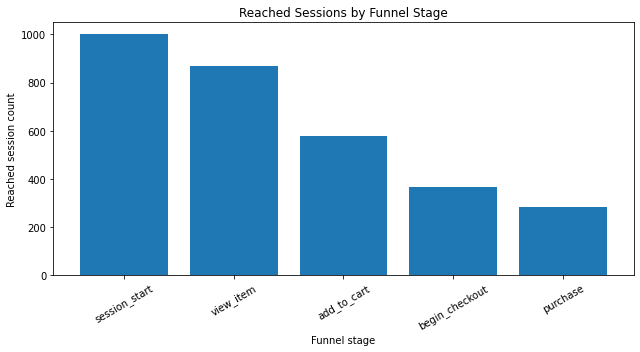

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(funnel_stage["funnel_stage"], funnel_stage["reached_session_count"])
ax.set_title("Reached Sessions by Funnel Stage")
ax.set_xlabel("Funnel stage")
ax.set_ylabel("Reached session count")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "01_funnel_stage_reached_sessions.png", dpi=150)
plt.show()

**해석:** 퍼널이 뒤 단계로 이동할수록 도달 세션 수가 감소합니다. synthetic data 결과이므로 실제 서비스의 전환 병목으로 일반화하지 않습니다.


## 3. 직전 단계 대비 전환율


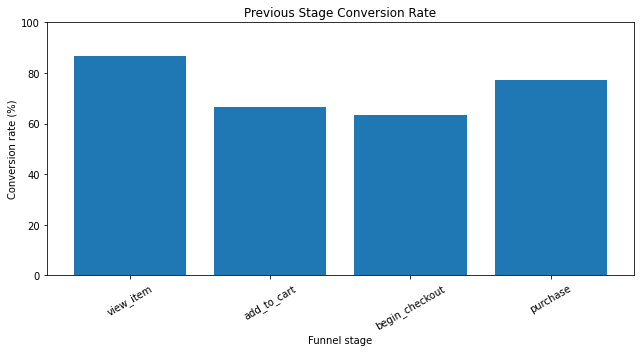

In [10]:
previous_stage_conversion = funnel_stage.dropna(subset=["previous_stage_conversion_rate"])

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(previous_stage_conversion["funnel_stage"], previous_stage_conversion["previous_stage_conversion_rate"])
ax.set_title("Previous Stage Conversion Rate")
ax.set_xlabel("Funnel stage")
ax.set_ylabel("Conversion rate (%)")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "02_previous_stage_conversion_rate.png", dpi=150)
plt.show()

**해석:** 단계별 전환율은 직전 단계에 도달한 세션을 기준으로 계산됩니다. synthetic data 기반 패턴이므로 실제 고객 여정의 전환율 수준으로 해석하지 않습니다.


## 4. 이탈 단계별 세션 수


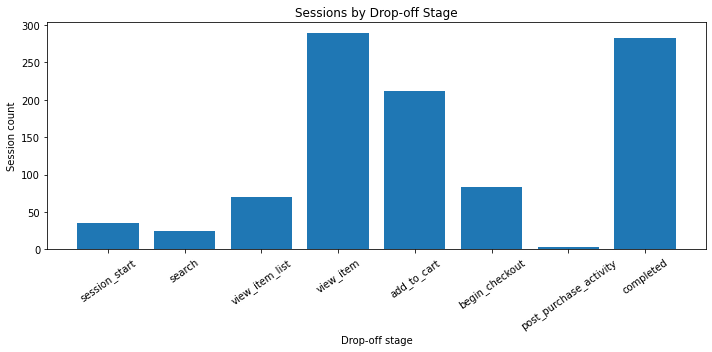

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(drop_off["drop_off_stage"], drop_off["session_count"])
ax.set_title("Sessions by Drop-off Stage")
ax.set_xlabel("Drop-off stage")
ax.set_ylabel("Session count")
ax.tick_params(axis="x", rotation=35)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "03_drop_off_stage_sessions.png", dpi=150)
plt.show()

**해석:** 이탈 단계별 세션 수는 synthetic data에서 정의된 여정 구조의 분포를 보여줍니다. 실제 서비스 개선 우선순위로 바로 일반화할 수 없습니다.


## 5. 구매/미구매 평균 행동량 비교


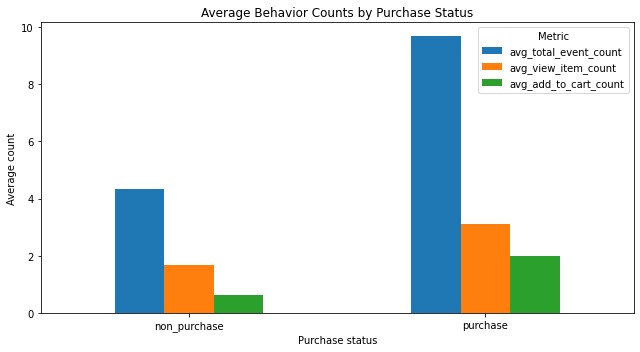

In [12]:
behavior_metrics = [
    "avg_total_event_count",
    "avg_view_item_count",
    "avg_add_to_cart_count",
]
behavior_plot = behavior_by_purchase.set_index("purchase_status")[behavior_metrics]

fig, ax = plt.subplots(figsize=(9, 5))
behavior_plot.plot(kind="bar", ax=ax)
ax.set_title("Average Behavior Counts by Purchase Status")
ax.set_xlabel("Purchase status")
ax.set_ylabel("Average count")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Metric")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "04_avg_behavior_by_purchase_status.png", dpi=150)
plt.show()

**해석:** 구매 세션은 미구매 세션보다 평균 행동량이 높게 나타납니다. 이는 synthetic data 내 생성 패턴의 결과이며, 실제 서비스에서 행동량 증가가 구매를 유발한다는 인과 해석은 할 수 없습니다.


## 6. 이벤트 도달 여부별 구매 전환율


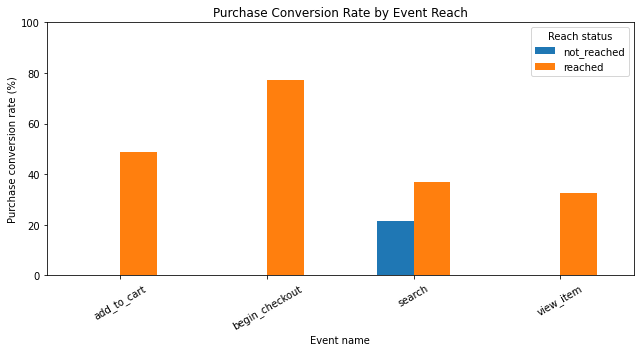

In [13]:
event_reach_plot = event_reach.copy()
event_reach_plot["reach_status"] = event_reach_plot["reached_event_flag"].map({0: "not_reached", 1: "reached"})
event_reach_pivot = event_reach_plot.pivot(
    index="event_name",
    columns="reach_status",
    values="purchase_conversion_rate",
)

fig, ax = plt.subplots(figsize=(9, 5))
event_reach_pivot.plot(kind="bar", ax=ax)
ax.set_title("Purchase Conversion Rate by Event Reach")
ax.set_xlabel("Event name")
ax.set_ylabel("Purchase conversion rate (%)")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=30)
ax.legend(title="Reach status")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "05_conversion_rate_by_event_reach.png", dpi=150)
plt.show()

**해석:** 특정 이벤트 도달 여부에 따라 구매 전환율 차이가 나타납니다. 다만 synthetic data 결과이므로 실제 서비스에서 해당 이벤트가 구매 전환을 설명하거나 보장한다고 일반화하지 않습니다.


## 7. 장바구니 추가 수 구간별 구매 전환율


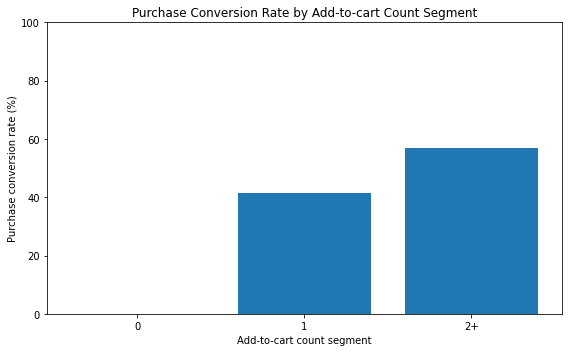

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(cart_segment["add_to_cart_count_segment"].astype(str), cart_segment["purchase_conversion_rate"])
ax.set_title("Purchase Conversion Rate by Add-to-cart Count Segment")
ax.set_xlabel("Add-to-cart count segment")
ax.set_ylabel("Purchase conversion rate (%)")
ax.set_ylim(0, 100)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "06_conversion_rate_by_add_to_cart_segment.png", dpi=150)
plt.show()

**해석:** 장바구니 추가 수가 많은 구간에서 구매 전환율이 높게 나타납니다. 이는 synthetic data의 집계 결과이며, 실제 서비스의 장바구니 전략 효과로 일반화하지 않습니다.


## 8. 리뷰 세션 유형별 비중


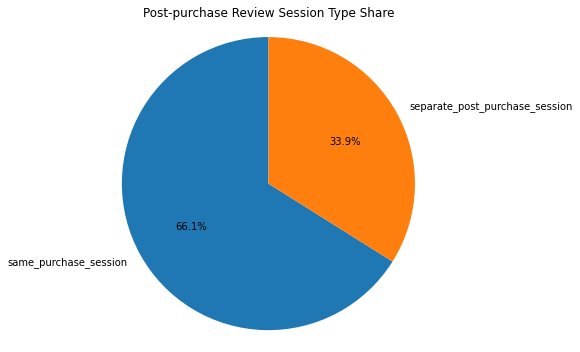

In [15]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.pie(
    review_type["review_type_rate"],
    labels=review_type["review_session_type"],
    autopct="%1.1f%%",
    startangle=90,
)
ax.set_title("Post-purchase Review Session Type Share")
ax.axis("equal")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "07_review_session_type_share.png", dpi=150)
plt.show()

**해석:** 리뷰가 발생한 세션 유형의 비중을 비교할 수 있습니다. synthetic data 기반 결과이므로 실제 리뷰 작성 행동의 일반적 경향으로 해석하지 않습니다.


## 저장 파일 목록

노트북 실행 시 아래 PNG 파일이 `outputs/figures/`에 저장됩니다.

- `01_funnel_stage_reached_sessions.png`
- `02_previous_stage_conversion_rate.png`
- `03_drop_off_stage_sessions.png`
- `04_avg_behavior_by_purchase_status.png`
- `05_conversion_rate_by_event_reach.png`
- `06_conversion_rate_by_add_to_cart_segment.png`
- `07_review_session_type_share.png`


## Logistic Regression baseline 결과 요약

- 모델 학습과 평가는 `scripts/model_logistic_regression.py`에서 수행했다.
- 노트북에서는 저장된 CSV 결과를 불러와 결과를 확인한다.
- `with_checkout` 모델은 `begin_checkout_count`, `has_begin_checkout`을 포함한다.
- `without_checkout` 모델은 구매 직전 행동인 `begin_checkout` 관련 변수를 제외한다.
- 본 데이터는 synthetic data이므로 실제 서비스 예측 성능으로 일반화하지 않는다.


In [ ]:
from pathlib import Path

model_output_dir = PROJECT_ROOT / "outputs" if "PROJECT_ROOT" in globals() else Path("outputs")
metrics_path = model_output_dir / "model_logistic_regression_metrics.csv"
without_checkout_coefficients_path = model_output_dir / "model_logistic_regression_coefficients_without_checkout.csv"
with_checkout_coefficients_path = model_output_dir / "model_logistic_regression_coefficients_with_checkout.csv"

metrics_df = pd.read_csv(metrics_path)
without_checkout_coefficients_df = pd.read_csv(without_checkout_coefficients_path)
with_checkout_coefficients_df = pd.read_csv(with_checkout_coefficients_path)

without_checkout_top10 = without_checkout_coefficients_df.sort_values(
    "abs_coefficient",
    ascending=False,
).head(10)
with_checkout_top10 = with_checkout_coefficients_df.sort_values(
    "abs_coefficient",
    ascending=False,
).head(10)

display(metrics_df)
display(without_checkout_top10)
display(with_checkout_top10)


`without_checkout` 모델도 F1 0.8889, ROC-AUC 0.9834로 높은 구분 성능을 보였다. 구매 직전 행동인 `begin_checkout`을 제외하더라도, 세션 내 전체 행동량과 장바구니 도달 여부가 구매 전환 여부를 구분하는 주요 신호로 나타났다.

coefficient 해석 시 `event_count`, `has_add_to_cart`는 주요 양의 신호로 나타났다. 일부 세부 행동 횟수 변수는 음의 계수를 보였지만, 이는 `event_count` 등과 정보가 중복되면서 계수 부호가 분산된 결과로 해석했다.

`session_duration_minutes`는 `purchase`, `review_write` 제외 기준으로 재정의하여 target leakage 가능성을 줄였다. 본 결과는 synthetic data 기반이므로 실제 서비스 성능으로 일반화하지 않고, feature 설계와 모델링 파이프라인 검증 결과로 해석했다.
